In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os
# sys.path.append('../')
# sys.path.append('../modules/')
# sys.path.append('../util/')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import torch
import random
from SFM_Finetune import models_Segmentation, models_Regression
from SFM_Pretrain import models_mae
from modules.modeling.deeplab import *
from modules.modeling.Unet_models import *
from util.metrics import *
from util.datasets import *


len(self.file_list) 2286422


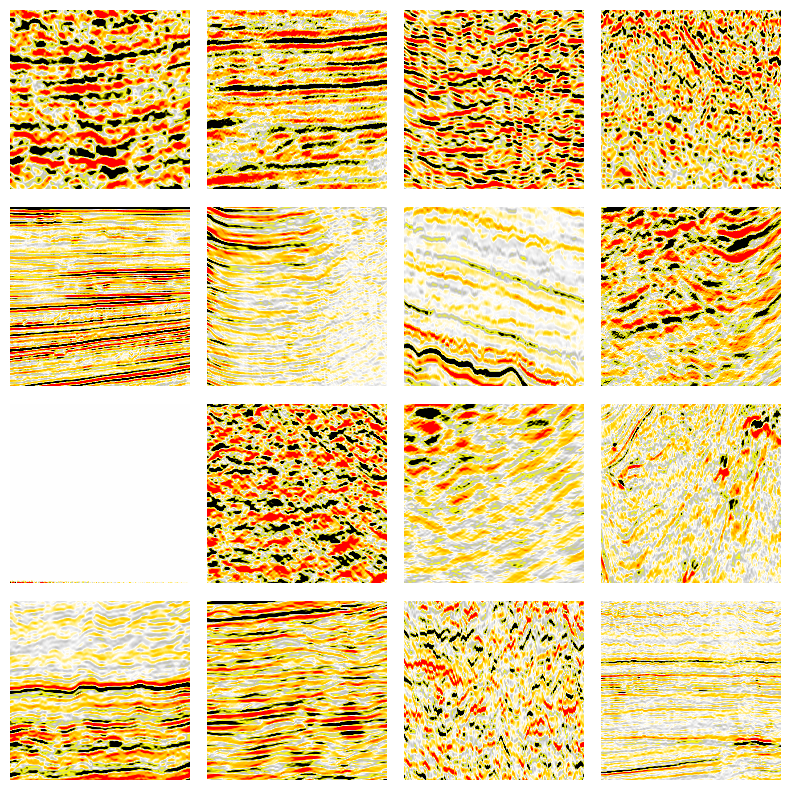

In [2]:
dat_path = "/home/zhangji/sdb1_data/Geophysics_data/mae_data_more.dat"
input_size = 224

dataset_train = SeismicSet_singleFile(dat_path, input_size)
color_list = ['black','yellow','silver','white','gold','orange','red']
cmap = mpl.colors.LinearSegmentedColormap.from_list('colormap_name', color_list)
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=np.array((10, 10)) * 0.8)
for i, axi in enumerate(axes.flatten()):
    data = dataset_train[i][0][0]
    axi.imshow(data, cmap=cmap, vmin=np.min(data)/3,vmax=-np.min(data)/3)
    axi.axis('off')
plt.tight_layout()
plt.subplots_adjust(wspace=0.1, hspace=0.1)
plt.show()

In [3]:
def prepare_model(chkpt_dir, arch='vit_large_patch16', img_size=768):
    # 检查是否有可用的GPU
    if torch.cuda.is_available():
        # 获取GPU的数量
        num_gpus = torch.cuda.device_count()
        print(f"Number of GPUs available: {num_gpus}")
    
        # 遍历每个GPU并打印详细信息
        for i in range(num_gpus):
            print(f"GPU {i} details:")
            # 获取GPU的名称
            gpu_name = torch.cuda.get_device_name(i)
            print(f"  Name: {gpu_name}")
            # 获取GPU的计算能力
            gpu_capability = torch.cuda.get_device_capability(i)
            print(f"  Compute Capability: {gpu_capability[0]}.{gpu_capability[1]}")
            # 获取GPU的显存总量
            gpu_memory = torch.cuda.get_device_properties(i).total_memory
            print(f"  Total Memory: {gpu_memory / 1e9:.2f} GB")
            # 获取GPU的当前占用显存
            gpu_current_memory = torch.cuda.memory_allocated(i)
            print(f"  Current Memory Allocated: {gpu_current_memory / 1e9:.2f} GB")
            # 获取GPU的当前缓存显存
            gpu_cached_memory = torch.cuda.memory_reserved(i)
            print(f"  Current Memory Cached: {gpu_cached_memory / 1e9:.2f} GB")

        # 选择内存使用量最小的显卡
        num_gpus = torch.cuda.device_count()
        min_memory_usage = float('inf')
        selected_gpu = None    
        for i in range(num_gpus):
            memory_allocated = torch.cuda.memory_allocated(i)
            if memory_allocated < min_memory_usage:
                min_memory_usage = memory_allocated
                selected_gpu = i
        print("GPU %d is selected." % selected_gpu)
        device = torch.device(f'cuda:{selected_gpu}')
    else:
        print("No GPU available.")
        device = torch.device('cpu')
        
    model = getattr(models_mae, arch)(norm_pix_loss=False, in_chans=1, img_size=img_size)
    checkpoint = torch.load(chkpt_dir, map_location=device)
#     interpolate_pos_embed(model, checkpoint['model'])
    msg = model.load_state_dict(checkpoint['model'], strict=False)
    print(msg)
    model.to(device)
    return model 

# chkpt_dir = '/home/zhangji/sdb1_data/Geophysics_data/Model/SFM-Base.pth' 
# model_SFM = prepare_model(chkpt_dir, 'mae_vit_base_patch16D4d256', img_size=224)

# chkpt_dir = '/home/zhangji/sdb1_data/Geophysics_data/Model/SFM-Large.pth' 
# model_SFM = prepare_model(chkpt_dir, 'mae_vit_large_patch16D4d256', img_size=224)

# chkpt_dir = '/home/zhangji/sdb1_data/Geophysics_data/Model/SFM-Base-512.pth' 
# model_SFM = prepare_model(chkpt_dir, 'mae_vit_base_patch16D4d256', img_size=512)

# chkpt_dir = '/home/zhangji/sdb1_data/Geophysics_data/Model/SFM-Large-512.pth' 
# model_SFM = prepare_model(chkpt_dir, 'mae_vit_large_patch16D4d256', img_size=512)

chkpt_dir = '/home/zhangji/LLM/Geophysics/output_dir/train_base_A100/checkpoint-1599.pth' 
model_SFM = prepare_model(chkpt_dir, 'mae_vit_base_patch16D4d256', img_size=224)

Number of GPUs available: 2
GPU 0 details:
  Name: NVIDIA GeForce RTX 2080 Ti
  Compute Capability: 7.5
  Total Memory: 11.55 GB
  Current Memory Allocated: 0.00 GB
  Current Memory Cached: 0.00 GB
GPU 1 details:
  Name: NVIDIA GeForce RTX 2080 Ti
  Compute Capability: 7.5
  Total Memory: 11.55 GB
  Current Memory Allocated: 0.00 GB
  Current Memory Cached: 0.00 GB
GPU 0 is selected.
<All keys matched successfully>


2089
(224, 224)


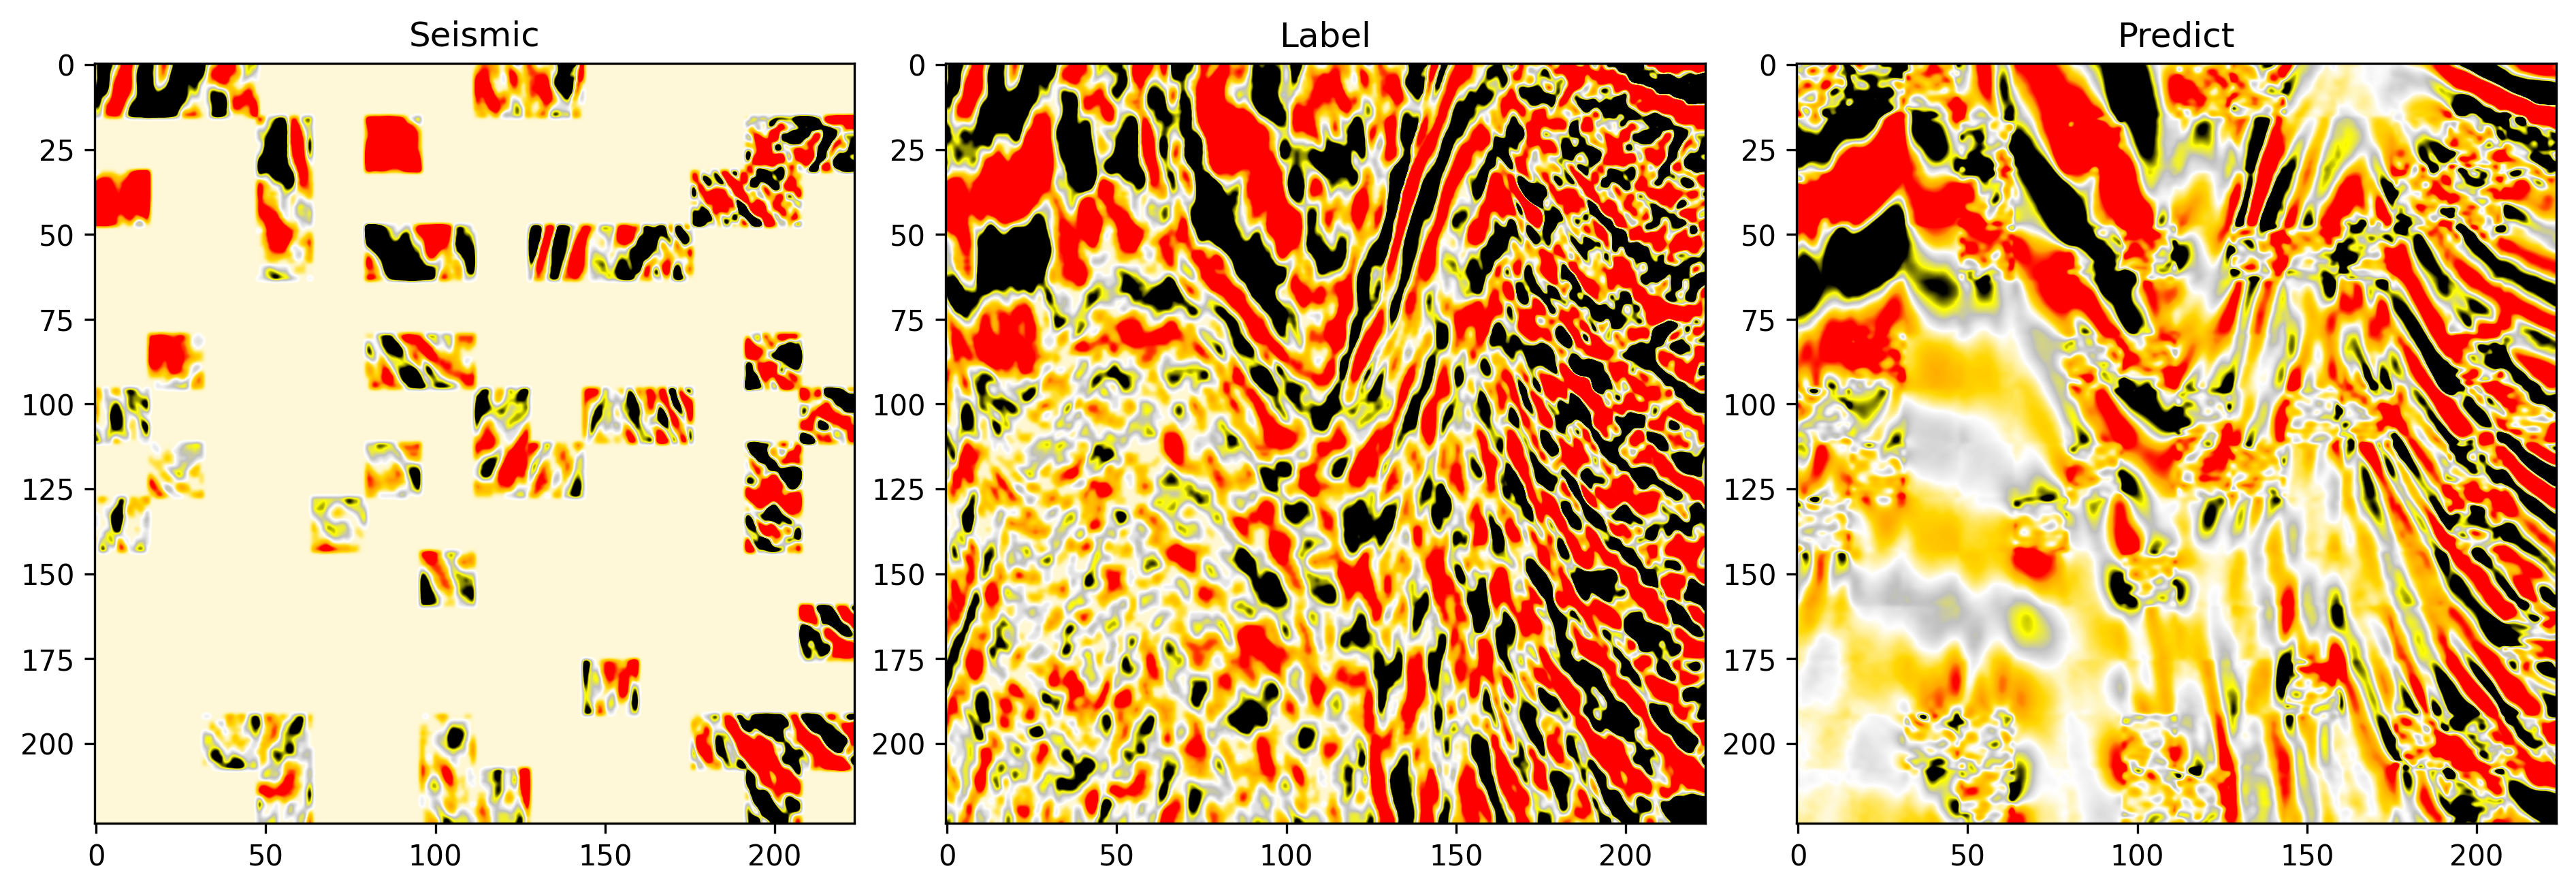

In [4]:
def expand_mask(mask, expansion_factor):
    """
    扩充 mask 矩阵，每个元素变成 expansion_factor * expansion_factor 的矩阵。
    
    参数:
    - mask: 输入的 mask 矩阵 (numpy array)
    - expansion_factor: 扩充因子，即每个元素要变成多大的子矩阵
    
    返回:
    - 扩充后的 mask 矩阵 (numpy array)
    """
    original_height, original_width = mask.shape
    expanded_height = original_height * expansion_factor[0]
    expanded_width = original_width * expansion_factor[1]
    expanded_mask = np.zeros((expanded_height, expanded_width))

    for i in range(original_height):
        for j in range(original_width):
            # 复制 mask[i, j] 到 4x4 的子矩阵中
            expanded_mask[i*expansion_factor[0]:(i+1)*expansion_factor[0],
                          j*expansion_factor[1]:(j+1)*expansion_factor[1]] = mask[i, j]

    return expanded_mask
    
def run_one_image(img, model, mask_ratio=0.1):
    color_list = ['#F19E9C','#EB5C56','#43972B','#FEE76B','#F3B677','#0082F4'] #seam
    cmapl = mpl.colors.LinearSegmentedColormap.from_list('colormap_name', color_list)
    color_list = ['black','yellow','silver','white','gold','orange','red']
    cmap = mpl.colors.LinearSegmentedColormap.from_list('colormap_name', color_list)
    device = next(model.parameters()).device
    model.eval()
    
    patch_size = np.array(model.patch_embed.patch_size) # [16 16]
    image_size = np.array(img.shape) # [224 224]
    expansion_factor = np.array(image_size / patch_size, dtype=int) # [14 14]
    # print(patch_size, image_size, expansion_factor)
    x = torch.tensor(img).to(device)
    x = x.unsqueeze(0).unsqueeze(0)    
    loss, pred, mask = model(x, mask_ratio=mask_ratio)
    pred = pred.detach().cpu()
    pred = pred.squeeze(0).reshape(*np.hstack((expansion_factor, patch_size)))
    pred = np.einsum('hwpq->hpwq', pred).reshape(*image_size)
    print(pred.shape)
    # x_masked = x_masked.squeeze(0).squeeze(0).detach().cpu()
    mask = expand_mask(mask.reshape(*expansion_factor).detach().cpu(), patch_size)
    x_masked = img * (1 - mask) # mask: 0 is keep, 1 is remove
    # print(mask)
    # print(mask.shape, x_masked.shape, x.shape)
    # print(mask.sum())
    
    figsize = np.array([25, 10]) * 0.5
    dpi = 300
    fig, axs = plt.subplots(1, 3, figsize=figsize, dpi=dpi, constrained_layout=True)
    axi = axs[0]
    axi.imshow(x_masked, cmap=cmap, interpolation='bicubic', vmin=x.min()/12, vmax=x.max()/12)
    axi.set_title("Seismic")
    axi = axs[1]
    axi.imshow(img     , cmap=cmap, interpolation='bicubic', vmin=x.min()/12, vmax=x.max()/12)
    axi.set_title("Label")
    axi = axs[2]
    axi.imshow(pred    , cmap=cmap, interpolation='bicubic', vmin=x.min()/12, vmax=x.max()/12)
    axi.set_title("Predict")
    
data_path = '/home/zhangji/sdb1_data/Geophysics_data/Data/Interpolation/'

dnum = np.random.randint(2000, 4000)
dnum = 2089
print(dnum)
d = np.fromfile(os.path.join(data_path, 'U%d.dat' % dnum), np.float32)
img_size = int(np.sqrt(d.size))
d = d.reshape((img_size, img_size))
# plt.imshow(d)
run_one_image(d, model_SFM, mask_ratio=0.75)